# Neural Networks - Mini-Batch Training

## 1. The Three Worlds: Batch, Stochastic and Mini-batch Gradient Descent

> It is impossible to compute exact gradients -> Stochastic gradients.

### From the First Principles

- $P$: distribution

**Expected risk** is defined:

$$
J(\theta) = \mathbb{E}_{(x,y)~P}[L(f_{\theta}(x),y)]
$$

- Expectation is all over future data, not just data we have.
- The thing is we don't know true distribution $P$ of the data.

**Empirical Risk**

- What we have is a dataset $D = {(x_1, y_1),..., (x_N, y_N)}$.
- Treat the dataset as a sample of real world -> Average the expectation:

$$
J(\theta) = \frac{1}{N}\sum_{i=1}^NL_i(\theta)
$$

Hence the gradient is also an average direction:

$$
\nabla J(\theta) = \frac{1}{N}\sum_{i=1}^N \nabla L_i(\theta)
$$

### World 1: Batch Gradient Descent

- From empirical risk, compute average gradient > update the params

$$
\theta \leftarrow \theta - \eta \nabla J(\theta)
$$

- It's **exact** gradient, but **slow**.

### World 2: Stochastic Gradient Descent (SGD)

- Choose one random example > compute its gradient > update params

$$
\nabla J(\theta) = \nabla L_i(\theta), \theta \leftarrow \theta - \eta\nabla L_i(\theta)
$$

- Though every example gives different gradient, if the sampling is fair, the average of examples reflects the whole population.

$$
\mathbb{E}(\nabla L_i) = \nabla J
$$

### World 3: Mini-batch Gradient Descent

- For $B$ is batch size (32, 64, 256,...), compute:

$$
\nabla J = \frac{1}{B}\sum_{i = 1}^B \nabla L_i(\theta)
$$

- If $B = 1$ -> SGD
- If $B = N$ -> Batch
- Mini-batch leverage the power of GPUs.

### Comparing the Worlds

In [4]:
import numpy as np

rng = np.random.default_rng(seed=42)

# Generate data
X = rng.random((1000, 1))
y = 3 * X.squeeze() + 2 + 0.2 * rng.random(1000)

# Add bias column
X = np.c_[np.ones(len(X)), X]

theta = np.zeros(2)
lr = .05

def gradient(theta, X_batch, y_batch):
    pred = X_batch @ theta
    return X_batch.T @ (pred - y_batch) / len(X_batch)

In [5]:
# Batch
theta_batch = theta.copy()

for _ in range(100):
    g = gradient(theta_batch, X, y)
    theta_batch -= lr * g

# SGD
theta_sgd = theta.copy()

for _ in range(100):
    i = np.random.randint(len(X))
    g = gradient(theta_sgd, X[i:i+1], y[i:i+1])
    theta_sgd -= lr * g

# Mini-batch
theta_mb = theta.copy()

for _ in range(100):
    idx = np.random.choice(len(X), 32, replace=False)
    g = gradient(theta_mb, X[idx], y[idx])
    theta_mb -= lr * g

print(theta_batch)
print(theta_sgd)
print(theta_mb)

[2.65490563 1.95194792]
[2.80851884 1.81511059]
[2.63880586 1.95222888]


## 2. Gradient Noise: Why Imperfect Gradients Can Be Better

- Don't just look at the equation $\mathbb{E}(g) = \nabla J(\theta)$ and satisfied.
- Expectation tells where a distribution is centred, but *not how wide it is*.
- The stochastic gradient of individual examples is **noise**.

### Variance - How wide is a distribution

- **Variance** = How much gradient fluctuates
- Large variance -> noisy
- Small variance -> smooth trajectory

$$
\text{Var}(g) = \mathbb{E}[(g - \mathbb[E])^2]
$$

- For vector gradients:

$$
\Sigma = \text{Cov}(g)
$$

- For mini-batches: $g_B = \frac{1}{B}\sum_{i=1}^B gi_i$, the Variance is:

$$
\text{Var}(g_B) = \text{Var}(\frac{1}{B} \sum g_i) = \frac{1}{B^2}\sum \text{Var}(g_i) = \frac{1}{B^2} B\text{Var}(g) \\

\Leftrightarrow \text{Var}(g_B) = \frac{1}{B}\text{Var}(g)
$$

- Increase $B$, variance doesn't disappear, it gradually decreases.

### Why noise can help

- Exact gradient descent -> stay in local opimum.
- With a little bit of noise -> sometimes it excapes bad local valleys, saddle points.

## 3. Statistical View of Mini-batching

- Mini-batch gradient = mean of a population.
- Precisely, mini-batching = Monte Carlo estimation:
  - Sample $g_1,..., g_B$
  - Compute $\mathbb{E}[g] = \hat{\mu} = \frac{1}{B}\sum_1^Bg_i$
  - Repeatedly estimating $\mathbb{E}[g]$.

> **Unbiasedness**: We expect $\mathbb{E}[\hat{g}] = g = \text{ true gradient}$

### Law of Large Numbers (LLN)

- When $B \rightarrow \infin: \frac{1}{B}\sum X_i = \mathbb{E}[X]$.

### Variance of the estimate and Standard error

- In statistics, variance is $\sigma^2$.
- Then mini-batch gradient: $\text{Var}(\hat{g}) = \frac{\sigma^2}{B}$.
- Standard error: $\text{SE} = \sqrt{\text{Var}(\hat{g})} = \frac{\sigma}{B}$
- Relationship Batch size and uncertainty: $\text{SE} \propto \frac{1}{\sqrt{B}}$

### Central Limit Theorem

- How estimate fluctuates
- $\hat{g}$ is approximately Gaussian.

$$
\hat{g} \approx \mathcal{N}(\mu, \frac{\sigma^2}{B})
$$

Define: $Z = \frac{X - \mu}{\sigma}$, then find $z$ such that 95% of the probability lies between $-z$ and $z$.

$$
P(-z < Z < z) = 0.95
$$

the remaining $z = 0.025$

- Cumulative Distribution Function (CDF) of a standard normal is: $\Phi(z) = P(Z \le z)$.
- We want $P(Z < z) = 0.975$
  - 95% in the middle
  - 2.5% in the right tail.
- Solve $\Phi(z) = 0.975 \Rightarrow z \approx 1.95996... \approx 1.96$.

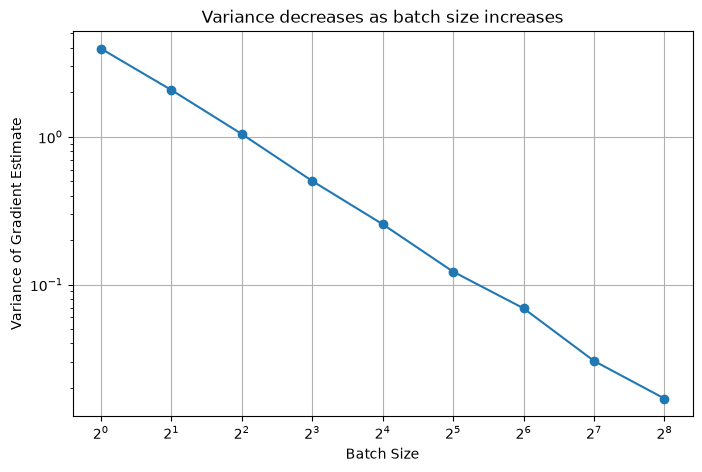

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate "true" gradients for a dataset
np.random.seed(42)
dataset_gradients = np.random.normal(loc=5.0, scale=2.0, size=10000)

true_gradient = np.mean(dataset_gradients)

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
variances = []

for B in batch_sizes:
    estimates = []

    for _ in range(500):
        batch = np.random.choice(dataset_gradients, B, replace=False)
        estimates.append(np.mean(batch))

    variances.append(np.var(estimates))

plt.figure(figsize=(8,5))
plt.plot(batch_sizes, variances, marker="o")
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Batch Size")
plt.ylabel("Variance of Gradient Estimate")
plt.title("Variance decreases as batch size increases")
plt.grid(True)
plt.show()

## 4. The Critical Batch Size

- **Diminishing return**: improvement speed decreases when batch size increases. Much more computation but tiny improvement.
- Increase Batch size -> Linearly increase cost -> But standard error (uncertainty) $\sigma$ decreases only $\sqrt{B}$.

### Signal and Noise

- Far from convergence: big signals, small noise -> big gradient
- Near convergence: signals and noise are similar -> tiny gradient
- Larger batch helps reduce uncertainty.
- **Gradient noise scale**: Compare noise to true gradient. For true gradient $g$

$$
G = \frac{\sigma^2}{\|g\|^2}
$$

- Big G = noisy gradients
- Small G = reliable gradients

### Critical Batch Size

- **Critical batch size**: the point where additional computation barely decreases the noise.
- Critical batch size is addaptive on:
  - model architecture
  - dataset
  - optimiser
  - learning rate
  - stage of training.

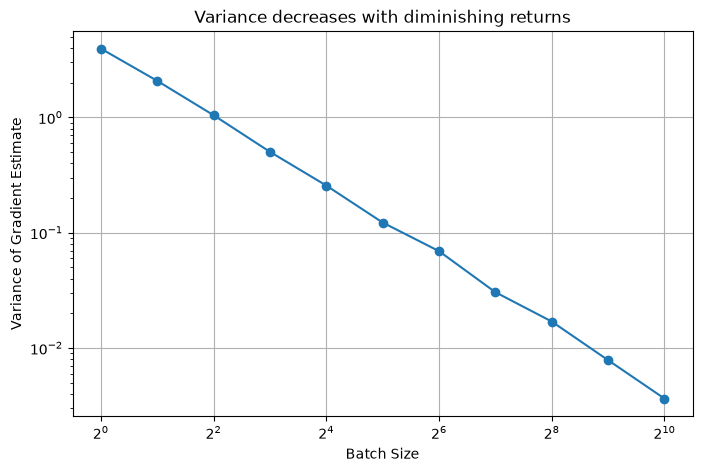

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulated dataset of per-example gradients
dataset_gradients = np.random.normal(loc=5.0, scale=2.0, size=10000)

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

variances = []

for B in batch_sizes:
    estimates = []

    for _ in range(500):
        batch = np.random.choice(dataset_gradients, B, replace=False)
        estimates.append(np.mean(batch))

    variances.append(np.var(estimates))

plt.figure(figsize=(8,5))
plt.plot(batch_sizes, variances, marker="o")
plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel("Batch Size")
plt.ylabel("Variance of Gradient Estimate")
plt.title("Variance decreases with diminishing returns")
plt.grid(True)
plt.show()

## 5. Small Batches vs Large Batches

- Optimisation vs Generatlisation
- Landscape: Sharp vs Flat
- Taylor Expanssion:

$$
L(\theta^* + \delta) \approx L(\theta^*) + \nabla L(\theta^*)^T\delta + \frac{1}{2}\delta^TH\delta
$$

At minimum, $\nabla L(\theta^*) = 0$

- Now Loss change depends on Hessian: large eigenvalues -> loss increase dramatically. small eigenvalues -> loss hardly changes.
- Sharpness (curvature) of Loss $\lambda_{\max}$ is maximum eigenvalue of Hessian $H = \nabla^2L(\theta)$.

### Why Hessian's eigvenvalues affecte the Loss with tiny perturbation?

- $\sigma^TH\sigma$ is a quadratic form, bounded by min and max eigenvalues of H.
- Hessian is symmetric -> **Eigendecomposition**

> **Spectral Theorem**: $H = H^T \rightarrow H = Q\Lambda Q^T$. $Q$ is an orthogonal matrix with eigenvector columns. $\Lambda$ is diagonal matrix of eigenvalues. -> **Eigendecomposition**.

Replace into the Taylor:

$$
\sigma^TH\sigma = \sigma^TQ\Lambda Q^T\sigma
$$

Let $Z = Q^T\sigma \Rightarrow \sigma^TH\sigma = Z^T\Lambda Z$.

Since $\Lambda$ is diagonal $\Rightarrow \sigma^TH\sigma = \sum_i \lambda_iz_i^2$.

- $\lambda_{\max}$ is used because in that direction, change a bit of that param increases dramatically the loss.
- $\lambda_{\max} =$ worst-case curvature. 

### Why Larger Batches have problems

- Larger batches = Lower gradient noise. -> marble rolling down smooth trajectory -> settles to any valley.
- Small batches = more noise -> marble can jump to escape local minima.
- Lower gradient noise -> deterministice trajectory -> settled narrow valleys -> lower training loss -> worse generalisation.

> Large Batches can find sharper minima.

### Is Flat always better?

- Flatness depends on how we measure distance in param space.
- Scaling one's layer's weights, but then inversely scaling the next layer -> function unchanges, only Hessian changes.
- Today, they use notions:
  - scale-invariant sharpness
  - PAC-Bayes flatness
  - local entropy
  - Sharpness-Aware Minimisation (SAM)
- The techniques they use to reduce the gap of large and small batches:
  - learning rate warm up
  - longer training
  - data augmentation
  - adaptive optimisers
  - SAM
  - careful learning rate scaling

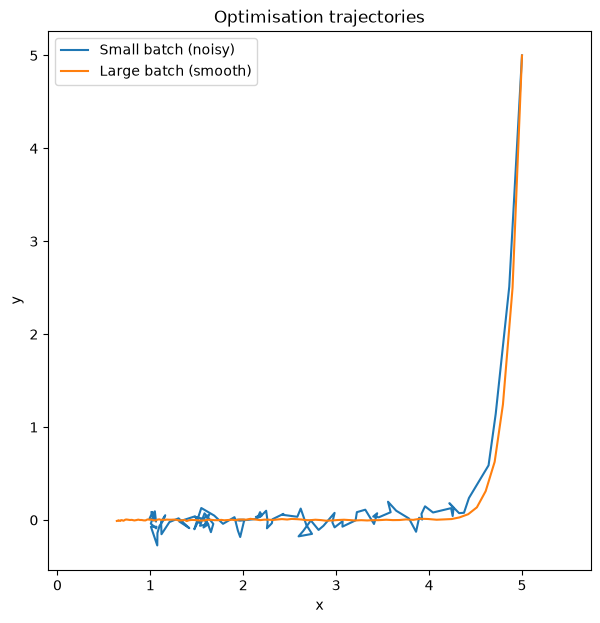

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def loss(theta):
    x, y = theta
    return 0.2 * x**2 + 5 * y**2

def grad(theta):
    x, y = theta
    return np.array([0.4 * x, 10 * y])

def sgd(theta, lr, noise_std, steps):
    path = [theta.copy()]
    for _ in range(steps):
        g = grad(theta)
        noise = np.random.normal(0, noise_std, size=2)
        theta = theta - lr * (g + noise)
        path.append(theta.copy())
    return np.array(path)

np.random.seed(42)

theta0 = np.array([5.0, 5.0])

small_batch_path = sgd(theta0.copy(), lr=0.05, noise_std=1.5, steps=100)
large_batch_path = sgd(theta0.copy(), lr=0.05, noise_std=0.1, steps=100)

plt.figure(figsize=(7,7))
plt.plot(small_batch_path[:,0], small_batch_path[:,1], label="Small batch (noisy)")
plt.plot(large_batch_path[:,0], large_batch_path[:,1], label="Large batch (smooth)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Optimisation trajectories")
plt.axis("equal")
plt.show()

## 6. Why Gradient Noise regularises Learning

- Noise = A little shake -> escape sharp minima (while flat minima is still harder to escape).
- Mini-batch version of SGD:

$$
\theta_{t + 1} = \theta_t - \eta \hat{g_t}
$$

while $\hat{g_t} = \nabla L(\theta_t) + \epsilon_t$. $\epsilon$ is random with $\mathbb{E}[\epsilon] = 0$.

Then we have:

$$
\theta_{t+1} - \theta_t = \eta\nabla L(\theta_t) - \eta\epsilon_t \\
\Rightarrow d\theta = -\nabla L(\theta)dt + \sqrt{2T}dW_t
$$

for:
- $d\theta$: infinitesimal change in params
- $-\nabla Ldt$: deterministic drift downhill
- $dW_t$: Brownian motion
- $T$: effective temperature related to the amount of gradient noise.

### How to think minima like entropy?

- Sharp minima > less points around minima > low entropy > optimisation spends less time to find minima.
- Flat minima > more points around minima > high entropy > optimisation spends more time to find minima.

### What other optimisation methods do researchers use?

- Stochastic Gradient Langevin Dynamics (SGLD)
- Entropy-SGD
- Sharpness-Aware Minimisation (SAM)

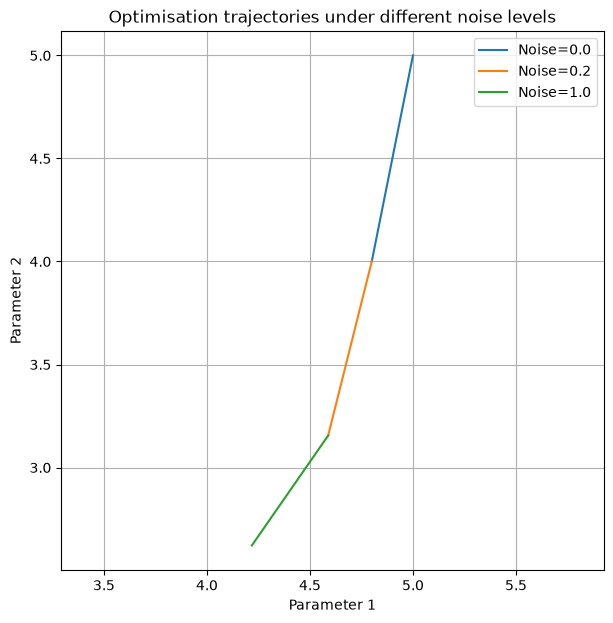

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def grad(theta):
    x, y = theta
    return np.array([0.4*x, 2.0*y])

def sgd(theta, lr, noise_std, steps):
    path = [theta.copy()]
    
    for _ in range(steps):
        g = grad(theta)
        noise = np.random.normal(0, noise_std, size=2)
        theta -= lr * (g + noise)
        path.append(theta.copy())
        return np.array(path)

np.random.seed(0)
theta0 = np.array([5.0, 5.0])
noise_levels = [0.0, 0.2, 1.0]
plt.figure(figsize=(7, 7))

for noise in noise_levels:
    path = sgd(theta0, lr=.1, noise_std=noise, steps=100)
    plt.plot(path[:, 0], path[:, 1], label=f"Noise={noise}")

plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Optimisation trajectories under different noise levels")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show();

## 7. Shuffling the Dataset

- Statistical assumption: **IID**:
  - **Independent**: samples are uncorrelated
  - **Identically Distributed**: batches' statistics = dataset's statistics
- Sorted dataset -> **Gradient bias**: $\mathbb{E}[\hat{g}] \ne \nabla L$ for $\hat{g} = \frac{1}{B}\sum_{i=1}^B\nabla l_i$.
- **Correrated gradients** between batches make optimisers oscillates between subsets of the data.
- Shuffle every epoch, not just once at the beginning.
- Curriculum learning.

### When shuffling is wrong?

- Time-Series data.

### How do they shuffle in modern training

- **Weighted sampling** for unbalanced dataset.
- **Distributed shuffling**
- **Bucketed batching** in NLP
- **Curriculum or adaptive sampling** when sampling distribution evolves during training.

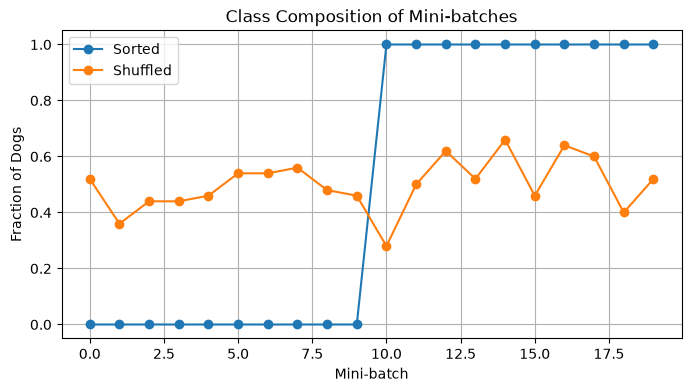

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic binary classification dataset
np.random.seed(42)

cats = np.random.normal(loc=-2, scale=0.8, size=(500, 2))
dogs = np.random.normal(loc=2, scale=0.8, size=(500, 2))

X = np.vstack([cats, dogs])
y = np.hstack([np.zeros(500), np.ones(500)])

# Sorted dataset
X_sorted = X.copy()
y_sorted = y.copy()

# Shuffled dataset
perm = np.random.permutation(len(X))
X_shuffled = X[perm]
y_shuffled = y[perm]

batch_size = 50

def class_fraction(labels):
    fractions = []
    for i in range(0, len(labels), batch_size):
        batch = labels[i:i+batch_size]
        fractions.append(batch.mean())
    return fractions

sorted_frac = class_fraction(y_sorted)
shuffled_frac = class_fraction(y_shuffled)

plt.figure(figsize=(8,4))
plt.plot(sorted_frac, marker="o", label="Sorted")
plt.plot(shuffled_frac, marker="o", label="Shuffled")
plt.xlabel("Mini-batch")
plt.ylabel("Fraction of Dogs")
plt.title("Class Composition of Mini-batches")
plt.legend()
plt.grid(True)
plt.show()

## 8. Data Loaders and Input Pipelines

### What is the problem with naive training approach?

- CPU and GPU takes turn to process and train sequently -> A lot of wait time -> inefficient!
- Pipelining: make multiple stages done by multiple hardware components simultaneously.
- CPU prepares the next batch when GPU trains on the current one.

### Synchronous and Asynchronous

- **Synchronous**: the take turn approach
- **Asynchronous**: the pipeline

### Workers

- 1 worker = 1 CPU thread
- Used to read and batch data
- in PyTorch, it is `num_workers`

### Prefetching

- **Prefetching**: another term to describe CPU preparing next batches.

### Pinned Memory

- CPU memory is pageable -> OS can pin (lock) the pages, make them not to move -> **pinned memory**.
- Allow **Direct Memory Access** (DMA) to transfer data to GPU more efficiently.

Normal memory: CPU > OS rearranges memory > GPU.

Pinned memory: CPU > GPU.

- In PyTorch, `pin_memory=True`.

### Throughput and Latency

- **Throughput** = number of batch processes per sec.
- **Latency** = How long one batch takes

### What does DataLoader do?

1. Select sample indices
2. Load the corresponding examples from storage
3. Apply preprocessing or augmentation
4. Group them into a mini-batch and hand it to the training loop

In PyTorch, it is hidden into this:

```python
for batch in dataloader:
    train(batch)
```

### Mini DataLoader from scratch

In [8]:
import numpy as np

class MiniDataLoader:

    def __init__(self, X, y, batch_size, shuffle=True, drop_last=True, transform=None):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.transform = transform

    def __iter__(self):
        indices = np.arange(len(self.X))

        if self.shuffle:
            np.random.shuffle(indices)
        
        for start in range(0, len(indices), self.batch_size):
            if self.drop_last and start + self.batch_size > len(indices):
                break
            batch_idx = indices[start:start + self.batch_size]

            batch_X = self.X[batch_idx]
            if self.transform:
                batch_X = self.transform(self.X[batch_idx])

            yield batch_X, self.y[batch_idx]
        

In [ ]:
loader = MiniDataLoader(X, y, batch_size=32)

for X_batch, y_batch in loader:
    # forward
    # backward
    # optimiser step
    pass

In [ ]:
def normalise(x):
    return x / 255.0

loader = MiniDataLoader(X, y, batch_size=32, shuffle=True, drop_last=True, transform=normalise)

## 9. Gradient Accumulation

- Sometimes we need large batch size that not fit into GPU memory.
- Divide Batch -> micro batches -> compute gradient of each micro batch -> average them.
- That's called **Gradient Accumulation**.

Suppose batch size is $B$, $K$ micro-batches, each has $m$ size ($m$ is also number of processed examples in one forward/backward pass). $B = Km$. Then:

Micro-batch loss:

$$
L_i = \frac{1}{m}\sum_j^m l_j
$$

Total loss:

$$
L = \frac{1}{K}\sum_i^K L_i = \frac{1}{Km} \sum_j^{Km} l_j
$$

Then gradient:

$$
\nabla L = \frac{1}{K}\sum_i^K \nabla L_i
$$

- The full process looks like this:

> (Forward > Backward > Accumulate) * n > Optimiser

### What are assumptions to use Gradient Accumulation?

- Fixed parameters
- Losses are averaged consistently
- Randomness is controlled

### When doesn't Gradient Accumulation work?

- Dropout samples different masks for each micro-batch
- Batch normalisation computes statistics differently for each micro-batch
- Data augmentation introduces different random transformations

In [9]:
import numpy as np

# Dummy linear regression

np.random.seed(42)

X = np.random.randn(1024, 10)
y = np.random.randn(1024)

w = np.zeros(10)

# Training

lr = .01
micro_batch = 128
accumulation_steps = 8

for epoch in range(5):
    permutation = np.random.permutation(len(X))

    X = X[permutation]
    y = y[permutation]

    accumulated_grad = np.zeros_like(w)

    counter = 0

    for start in range(0, len(X), micro_batch):
        xb = X[start:start + micro_batch]
        yb = y[start:start + micro_batch]

        pred = xb @ w
        grad = xb.T @ (pred - yb) / len(xb)

        accumulated_grad += grad
        counter += 1

        if counter == accumulation_steps:
            accumulated_grad /= accumulation_steps

            w -= lr * accumulated_grad
            accumulated_grad[:] = 0
            counter = 0

## 10. Large Batch Training

- Recall from statistics, increase batch size -> less noise:
- Mini Batch gradient is Monte Carlo of the whole, it is mean, and which has mean, has variance.

$$
\text{Var}(\hat{g}_n) = \frac{\sigma^2}{n}
$$

### Linear scaling rule

- k step case: $\theta \leftarrow \theta -\frac{k\eta}{n}\sum_1^n g_i = \theta - k\eta g$
- 1 step of kn-size batch: $\theta \leftarrow \theta - \frac{\eta}{kn}\sum_1^{kn} g_i = \theta - \eta g$.
- Assume all $g_i = g$, then the updated path in both equations are now a comparison between k for the first case and 1 for the second case.
- k > 1 hence $\theta_k < \theta_1$
- The kn size makes the training slower for the same learning rate.
- To make they remain the same, set $\eta' = k\eta$ when increase the batch size.

> **Linear Scaling Rule**: Multiply learning rate by k if batch size is multiplied by k. Goyal et al. used this trick to train ResNet-50 on ImageNet in **1 hour** instead of days.

- **Assumption**: all $g_i = g$ - i.e., the gradient is constant across steps.

### When assumption breaks?

- In small steps (k step case), gradient is stable, $g_i = g$.
- But a large batch, we compute average of all $kn$ gradients at one -> Huge step -> **Overshoot**.
- The whole leap only measures $k\eta g$ that the start, and that gradient is local on the loss surface = direction of a small step.
- To solve this problem, use **Learning Rate Warm-up**.

### How Learning Rate Warm-up solve the Overshoot problem?

- How it works: Start with small $\eta$, even near zero. Gradually increase learning rate until the model stabilises after first hundreds/thounsands steps.

$$
\eta(t) = \eta' \cdot \min(1, \frac{t}{T_{\text{warmup}}})
$$

### Square Root Scaling

- When batch size increases
  - gradient variance decreases by $\frac{1}{B}$
  - gradient standard deviation decreases by $\frac{1}{\sqrt{B}}$
- So scale learning rate by $\sqrt{k}$ ->

$$
\eta' = \eta \sqrt{k}
$$

### When to use which?

- There's no law
- Use **Linear Scaling** for SGD with warm-up, vision tasks, ImageNet training
- Use **Square Root Scaling** when you need to play it safely, unstable optimisation, very large batch size.

### Play Toy

#### Train the same neural network with the following configurations:

- Batch = 32, Learning Rate = 0.01
- Batch = 128, Learning Rate = 0.01 (no scaling)
- Batch = 128, Learning Rate = 0.04 (linear scaling)

Plot the training loss versus epochs for all three runs.

**Questions**:

1. Which configuration converges fastest?
2. Does linear scaling recover the performance lost by increasing the batch size?
3. Are the final losses similar?

In [11]:
class LogisticRegression:

    def __init__(self, input_dim):
        self.W = np.random.randn(input_dim, 1) * 0.1
        self.b = np.zeros((1,))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        z = X @ self.W + self.b
        return self.sigmoid(z)

    def loss(self, pred, y):
        eps = 1e-8
        pred = np.clip(pred, eps, 1 - eps)
        y = y.reshape(-1, 1)

        return -np.mean(
            y * np.log(pred) +
            (1-y) * np.log(1-pred)
        )

    def backward(self, X, pred, y):
        y = y.reshape(-1,1)
        dz = pred - y
        dW = X.T @ dz / len(X)
        db = np.mean(dz)

        return dW, db

    def step(self, dW, db, lr):
        self.W -= lr * dW
        self.b -= lr * db

In [12]:
def train(batch_size,
          lr,
          epochs=40,
          warmup=False):

    model = LogisticRegression(2)
    losses = []
    target_lr = lr
    initial_lr = 0.01

    for epoch in range(epochs):
        if warmup and epoch < 5:
            lr = initial_lr + (target_lr-initial_lr) * (epoch+1)/5
        else:
            lr = target_lr

        loader = MiniDataLoader(
            X,
            y,
            batch_size=batch_size,
            shuffle=True
        )

        epoch_loss = []

        for xb, yb in loader:
            pred = model.forward(xb)
            loss = model.loss(pred, yb)
            dW, db = model.backward(
                xb,
                pred,
                yb
            )
            model.step(dW, db, lr)
            epoch_loss.append(loss)
        losses.append(np.mean(epoch_loss))

    return losses

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data

np.random.seed(42)
n = 1000

X0 = np.random.randn(n//2, 2) + np.array([-2, -2])
X1 = np.random.randn(n//2, 2) + np.array([2, -2])

X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(n//2), np.ones(n//2)])

# Shuffle once
perm = np.random.permutation(n)
X = X[perm]
y = y[perm]

In [13]:
loss32 = train(
    batch_size=32,
    lr=0.01
)

loss128 = train(
    batch_size=128,
    lr=0.01
)

loss128_scaled = train(
    batch_size=128,
    lr=0.04
)

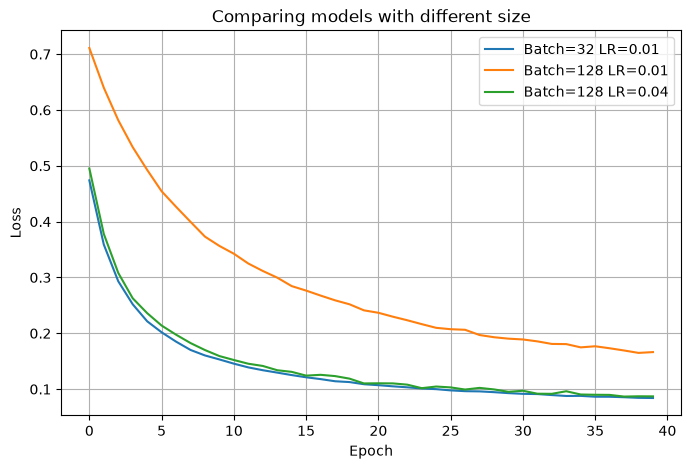

In [14]:
# Plot

plt.figure(figsize=(8, 5))
plt.plot(loss32, label="Batch=32 LR=0.01")
plt.plot(loss128, label="Batch=128 LR=0.01")
plt.plot(loss128_scaled, label="Batch=128 LR=0.04")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparing models with different size")
plt.legend()
plt.grid(True)
plt.show();

For the large-batch experiment (Batch = 128, Learning Rate = 0.04), compare two strategies:

- Constant learning rate of 0.04 from the first iteration.
- Linearly increase the learning rate from 0.01 to 0.04 over the first 5 epochs, then keep it at 0.04.

Plot the training loss for both.

**Questions**:

1. Which run is more stable during the first few epochs?
2. Does warm-up reduce oscillations or divergence?
3. Why is warm-up especially important for large-batch training?

In [15]:
loss_constant = train(
    batch_size=128,
    lr=0.04,
    warmup=False
)

loss_warmup = train(
    batch_size=128,
    lr=0.04,
    warmup=True
)

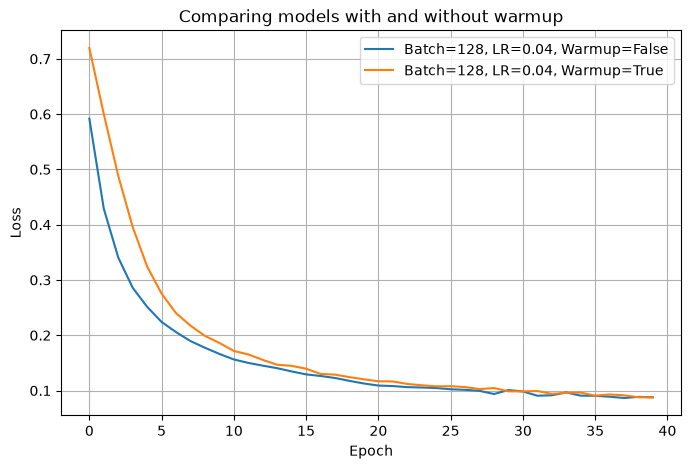

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(loss_constant, label="Batch=128, LR=0.04, Warmup=False")
plt.plot(loss_warmup, label="Batch=128, LR=0.04, Warmup=True")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparing models with and without warmup")
plt.legend()
plt.grid(True)
plt.show();

-> Warm-up helps not shrink the loss early, but eventually it decreases but less fluctuates.

## 11. Batch Normalisation and Batch Size

- How to keep each layer's input distribution stable while the weights in the prev layers keep updating?

### How does BatchNorm work?

- BatchNorm use **z-score normalisation**. For activation values $a_i$:
  - Compute batch mean: $\mu_B = \frac{1}{m} \sum_{i=1}^m a_i$
  - Compute batch variance: $\sigma^2 = \frac{1}{m}\sum_{i=1}{m}(a_i - \mu_B)^2$
  - Standardise: $\hat{a}_i = \frac{a_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$
- By this way, we normalise $\mu = 0, \sigma = 1$.
- But some model want to express more than that (e.g., $\mu = 5, \sigma = 9$) -> two learnable params:
  - $\gamma$: scale
  - $\beta$: shift

$$
y_i = \gamma \hat{x}_i + \beta
$$

Initially, $\gamma = 1, \beta = 0$. But during training, backprop learns the best values of $\gamma, \beta$.

- In practice, choose $\gamma$ = target mean, and $\beta$ = target standard deviation.

### How batch size relates to BatchNorm?

- Statistics in BatchNorm is local -> It doesn't work well on **small batch size**.
- **Ghost BatchNorm**: Split batch -> smaller "ghost" batches > compute BatchNorm on each ghost batch.
- **LayerNorm**: Normalise across the features of each individual sample. Statistics are independent of batch size. (e.g., Transformers use LayerNorm)
- **GroupNorm**: sit between the above. In computer vision, divide the channels into groups and normalises within each group.

### How BatchNorm works in Inference?

- In inference, only one example is predicted at a time.
- Maintain running estimates of mean and variance using Exponential Moving Average

$$
\mu_{\text{running}} \leftarrow (1 - \alpha)\mu_{\text{running}} + \alpha\mu_B
$$

- In PyTorch, $\alpha$ is (1 - `momentum`)

$$
\mu_{\text{running}} = \text{momentum}\times\mu_{\text{running}} + (1 - \text{momentum})\times\mu_B
$$

In [ ]:
class BatchNorm1D:

    def __init__(self, num_features, momentum=0.9, eps=1e-5):
        
        pass

    def forward(self, X, training=True):
        """
        1. Compute the batch mean and variance during training.
        2. Normalise the activations.
        3. Apply learnable parameters gamma and beta
        4. Update running mean and running variance using an exponential moving average.
        5. During inference (training=False), use the running statistics instead of the current batch.
        """
        pass

In [ ]:
np.random.seed(0)
X = np.random.randn(8, 4)
bn = BatchNorm1D(num_features=4)
Y = bn.forward(X, training=True)

print(Y.mean(axis=0))
print(Y.var(axis=0))

## 12. Distributed Mini-batching

- Many GPUs, but train only one model.
- **Data Parallelism**: Split mini-batch, each GPU owns a copy of the same model.
- Each worker computes $g_i = \frac{1}{B}\sum_{j \in B_i}g_j$, for $B$ is Batch size.
- Then the gradient ò the full batch is average ò the gradients.

### What are the Three Batch Sizes

- **Local batch**: batch size on one GPU
- **Global batch**: local batch * # workers
- **Effective batch**: local batch * # workers * gradient accumulation

### How does the full timeline look like?

> Load local batch > forward > backward > local gradient > communicate > average gradients > optimiser > repeat

### How is the communication a problem?

- 7 bil params (each 4 bytes - FP32) = 28GB
- 70 bil = 280GB -> HUGE!!! size to communicate between each GPU with every other GPU.
- One solution is **AllReduce**.
- Processing time is also a problem.
- Strong scaling: fixed data, more GPUs
- Weak scaling: more data, more GPUs
- Synchronous vs asynchronous

### How does AllReduce work?

- All GPUs are in a cycle ring.
- Each GPU computes gradient, moves the gradient around the ring indepently.
- Reduce-Scatter phase: one GPU sends one chunk to the next GPU. When a GPU receives a chunk, it adds to its own. (e.g., GPU2 receive A1 from GPU1, now it has A1+A2. GPU2 computes A1+A2 then send it to the next GPU3... Eventually A1+A2+A3+A4)
- AllGather phase: Each GPU has total chunk
- Communication in parallel

$$
w_{t+1} = w_t - \eta(\frac{1}{K}\sum_{k=1}^K g_k)
$$

Imagine gradient is $g = [A, B, C, D]$,split into 4 chunks A, B, C, D.

Now each GPU computes local gradient.

| GPU  |    A |    B |    C |    D |
| ---- | ---: | ---: | ---: | ---: |
| GPU1 |    1 |    2 |    3 |    4 |
| GPU2 |   10 |   20 |   30 |   40 |
| GPU3 |  100 |  200 |  300 |  400 |
| GPU4 | 1000 | 2000 | 3000 | 4000 |

Consider chunk A.

Simultaneously:
- Round 1:
  - GPU1 sends 1 to GPU2 = 1 + 10 = 11
  - GPU2 sends 10 to GPU3 = 10 + 100 = 110
  - GPU3 sends 100 to GPU4 = 100 + 1000 = 1100
  - GPU4 sends 1000 to GPU1 = 1000 + 1 = 1001
- Round 2:
  - GPU1 sends 1000 to GPU2 = 1000 + 1 + 10 = 1011
  - GPU2 sends 1 to GPU3 = 1 + 10 + 100 = 111
  - GPU3 sends 10 to GPU4 = 10 + 100 + 1000 = 1110
  - GPU4 sends 100 to GPU1 = 100 + 1000 + 1 = 1101
- Roun 3:
  - Move again, eventually GPU4 receives 111 adds 1000, giving 1111.